#Estensione dell'idea del paper sull'esercizio Windy Gridworld

In questo notebook presentiamo l'esercizio svolto a lezione e aggiungiamo un confronto tra tre varianti

- **Baseline**: addestramento con \(\gamma_{train}=\gamma_{eval}\), nessuna regolarizzazione.
- **Discount regularization**: addestramento con \(\gamma_{train}<\gamma_{eval}\).
- **Regolarizzazione esplicita (L2 su \(Q\))**: addestramento con \(\gamma_{train}=\gamma_{eval}\) e penalità su \(Q(s,a)^2\).

E' stato implementato il codice di Windy Gridword delle esercizationi del corso di Reinforcement Learning dell'Università Milano-Bicocca, fornito da Vincenzina Messina e Antonio Consolo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ENVIRONMENT
from dataclasses import dataclass
import numpy as np

@dataclass
class StepResult:
    next_state: tuple
    reward: float
    done: bool

class WindyGridworld:
    """
    Windy Gridworld environment (Sutton & Barto style).

    - wind_strengths / self.wind: a list of integers (length = number of columns).
      Each entry gives the wind strength in that column: how many cells the agent
      is pushed *upward* each step. If None is given, a default pattern is used.

    - In step():
        1. Apply the chosen action (up, down, left, right).
        2. Read the wind strength of the destination column.
        3. Optionally add stochastic variation (±1 with probability stoch_p).
        4. Subtract that value from the row index (agent pushed upward).
        5. Clip the position to stay within the grid.

    - Example: if wind[6] = 2 and the agent moves to row=4, col=6,
      the wind pushes it to row=max(0, 4-2) = 2, col=6.
    """

    ACTIONS = [(-1,0),(1,0),(0,-1),(0,1)]  # up,down,left,right
    N_ACTIONS = 4

    def __init__(self, rows=7, cols=10, start=(3,0), goal=(3,7),
                 wind_strengths=None, max_steps=500,
                 stochastic=False, stoch_p=0.3, seed=0):
        self.rng = np.random.default_rng(seed)
        self.rows, self.cols = rows, cols
        self.start, self.goal = start, goal
        self.max_steps, self.stochastic, self.stoch_p = max_steps, stochastic, stoch_p

        if wind_strengths is None:
            self.wind = [0,0,0,1,1,1,2,2,1,0]
        else:
            assert len(wind_strengths) == cols, \
                "len(wind_strengths) must equal number of columns (cols)"
            self.wind = list(wind_strengths)

        self.reset()

    def reset(self):
        self.state = self.start
        self.t = 0
        return self.state

    def step(self, a: int) -> StepResult:
        r, c = self.state
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.rows-1, r + dr))
        nc = max(0, min(self.cols-1, c + dc))

        # wind effect
        w = self.wind[nc]
        if self.stochastic and (self.rng.random() < self.stoch_p):
            w = max(0, w + self.rng.integers(-1, 2))
        nr = max(0, nr - w)

        self.state = (nr, nc)
        self.t += 1

        done = (self.state == self.goal) or (self.t >= self.max_steps)
        reward = 0.0 if self.state == self.goal else -1.0
        return StepResult(self.state, reward, done)


In [ ]:
# Q-table and policies utilities
def init_Q(env):
    # Q(s,a) initialized to zeros: shape = (rows, cols, actions)
    return np.zeros((env.rows, env.cols, env.N_ACTIONS))

# rng is a np.random.default_rng object
def eps_greedy(qrow, eps, rng):
    # epsilon-greedy: with prob epsilon pick random action, else argmax Q
    return rng . integers ( len ( qrow ) ) if rng . random () < eps else int ( np.argmax ( qrow ) )


def greedy_action(Q, s):
    # Argmax action at state s (purely greedy policy)
    r, c = s
    return int ( np . argmax ( Q [r , c , :]) )

def pick_action(Q, s, eps, rng):
    # Select action at state s using epsilon-greedy on Q
    r, c = s
    return eps_greedy(Q[r, c, :], eps, rng)

def plot_curves(curves, ylabel="Return"):
    # Plot learning curves: one line per (label -> values)
    for label, vals in curves.items():
        plt.plot(vals, label=label)
    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

In [ ]:
##  A - Implement SARSA update (modify Q in place)
def sarsa_update(Q, s, a, r, s_next, a_next, alpha, gamma):
#  : implement SARSA update
    r0 , c0 = s ; r1 , c1 = s_next
    td_target = r + gamma * Q [ r1 , c1 , a_next ]
    td_error = td_target - Q [ r0 , c0 , a ]
    Q [ r0 , c0 , a ] += alpha * td_error


##  B - Implement Q-learning update (modify Q in place)
def q_learning_update(Q, s, a, r, s_next, alpha, gamma):
    # : implement Q-learning update
    r0 , c0 = s ; r1 , c1 = s_next
    td_target = r + gamma * np . max ( Q [ r1 , c1 ,:])
    td_error = td_target - Q [ r0 , c0 , a ]
    Q [ r0 , c0 , a ] += alpha * td_error

In [ ]:
def train_sarsa(env, episodes=200, alpha=0.5, gamma=1.0, eps=0.1, seed=0):
    rng = np.random.default_rng(seed)
    Q = init_Q(env); returns = []
    for ep in range(episodes):
        s = env.reset()                         # start new episode
        a = pick_action(Q, s, eps, rng)         # epsilon-greedy action at start state
        G = 0.0; done = False
        while not done:
            ns = env.step(a)                    # env transition using action a
            s_next, r, done = ns.next_state, ns.reward, ns.done
            G += r
            if not done:
                a_next = pick_action (Q , s_next , eps , rng )      # on-policy next action
                sarsa_update (Q , s , a , r , s_next , a_next , alpha , gamma )
                s , a = s_next , a_next                          # move along the trajectory
            else:
                # Terminal backup (no bootstrap): target = r
                r0, c0 = s
                Q [ r0 , c0 , a ] += alpha * ( r - Q [ r0 , c0 , a ])
        returns.append(G)                        # episodic return
    return Q, returns


def train_qlearning(env, episodes=200, alpha=0.5, gamma=1.0, eps=0.1, seed=0):
    rng = np.random.default_rng(seed)
    Q = init_Q(env); returns = []
    for ep in range(episodes):
        s = env.reset()                         # start new episode
        G = 0.0; done = False
        while not done:
            a = pick_action(Q, s, eps, rng)     # behavior policy: epsilon-greedy
            ns = env.step(a)                    # env transition
            s_next, r, done = ns.next_state, ns.reward, ns.done

            q_learning_update (Q , s , a , r , s_next , alpha , gamma )
            s = s_next
            G += r

        returns.append(G)
    return Q, returns

In [ ]:
# ---------- Experiment 1: SARSA vs Q-learning, deterministic vs stochastic wind ----------
def make_env(stochastic=False, seed=0, rows=7, cols=10, start=(3,0), goal=(3,7),
             wind_strengths=None, max_steps=500, stoch_p=0.3):
    """
    Helper to build a WindyGridworld with desired wind mode.
    - stochastic=False => deterministic wind
    - stochastic=True  => wind perturbed by ±1 with prob stoch_p
    """
    return WindyGridworld(
        rows=rows, cols=cols, start=start, goal=goal,
        wind_strengths=wind_strengths, max_steps=max_steps,
        stochastic=stochastic, stoch_p=stoch_p, seed=seed
    )

def run_one(algo, env_cfg, episodes=200, alpha=0.5, gamma=1.0, eps=0.1, seed=0):
    """
    Run a single training session for a given algo ('sarsa' or 'qlearning')
    and return the per-episode returns.
    """
    env = make_env(**env_cfg, seed=seed)
    if algo == 'sarsa':
        Q , returns = train_sarsa ( env , episodes = episodes , alpha = alpha , gamma = gamma , eps = eps , seed = seed )
    elif algo == 'qlearning':
       Q , returns = train_qlearning ( env , episodes = episodes , alpha = alpha , gamma = gamma , eps = eps , seed = seed )
    else:
        raise ValueError("algo must be 'sarsa' or 'qlearning'")
    return np.array(returns)

def average_runs(algo, env_cfg, episodes=200, alpha=0.5, gamma=1.0, eps=0.1, runs=10, base_seed=0):
    """
    Repeat training with different seeds and average returns across runs.
    Returns (mean_returns, std_returns) arrays of shape [episodes].
    """
    all_returns = []
    for k in range(runs):
        seed = base_seed + k
        rets = run_one(algo, env_cfg, episodes=episodes, alpha=alpha, gamma=gamma, eps=eps, seed=seed)
        all_returns.append(rets)
    all_returns = np.stack(all_returns, axis=0)                # [runs, episodes]
    return all_returns.mean(axis=0), all_returns.std(axis=0)

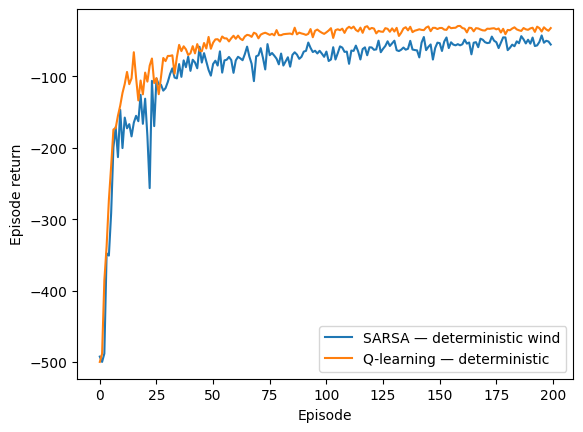

In [ ]:
# Compare SARSA vs Q-learning under:
#      - Deterministic wind (stochastic=False)
#      - Stochastic wind   (stochastic=True, stoch_p given)
#    Averages over multiple runs and plots the learning curves.
import matplotlib.pyplot as plt
episodes=200
alpha=0.5
gamma=1.0
eps=0.4
runs=20
base_seed=0
stoch_p=0.6
wind_strengths=None


# Env configs for both wind modes
det_cfg = dict(stochastic=False, stoch_p=stoch_p, wind_strengths=wind_strengths)
sto_cfg = dict(stochastic=True,  stoch_p=stoch_p, wind_strengths=wind_strengths)

# Compute mean curves
sarsa_det_mean, _ = average_runs('sarsa',     det_cfg, episodes, alpha, gamma, eps, runs, base_seed)
ql_det_mean,   _  = average_runs('qlearning', det_cfg, episodes, alpha, gamma, eps, runs, base_seed+1000)

sarsa_sto_mean, _ = average_runs('sarsa',     sto_cfg, episodes, alpha, gamma, eps, runs, base_seed+2000)
ql_sto_mean,   _  = average_runs('qlearning', sto_cfg, episodes, alpha, gamma, eps, runs, base_seed+3000)

# Plot (lower is worse; returns are typically negative until reaching the goal faster)
curves_det = {
    "SARSA — deterministic wind":   sarsa_det_mean,
    "Q-learning — deterministic":   ql_det_mean,
}

curves_stoc = {
    "SARSA — stochastic wind":      sarsa_sto_mean,
    "Q-learning — stochastic":      ql_sto_mean,
}
# Reuse your helper: accepts dict[label -> sequence]
plot_curves(curves_det, ylabel="Episode return")



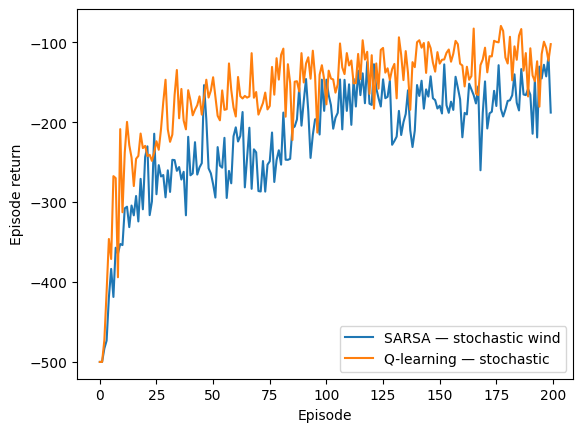

In [ ]:
plot_curves(curves_stoc, ylabel="Episode return")

In [ ]:
def rollout_episode(env, Q, epsilon=0.0, seed=123, max_steps=None):
    """
    Run one episode using epsilon-greedy policy w.r.t. Q (epsilon=0 => greedy).
    Returns the list of visited states (the path), including the start state.
    """
    rng = np.random.default_rng(seed)           # deterministic randomness for reproducibility
    s = env.reset()
    path = [s]
    done = False
    steps = 0
    max_steps = max_steps or env.max_steps      # cap episode length
    while (not done) and steps < max_steps:
        while ( not done ) and steps < max_steps :
            # epsilon - greedy action selection
            if rng . random () < epsilon :
                a = rng . integers ( env . N_ACTIONS ) # random action
            else :
                a = greedy_action (Q , s ) # greedy action from Q
            step = env . step ( a ) # environment transition
            s = step . next_state
            path . append ( s ) # record next state
            done = step . done
            steps += 1
    return path

In [ ]:
# --- 1) Train SARSA with two exploration settings (same alpha/episodes you use in the study) ---
env_cfg = dict(stochastic=True, rows=7, cols=10, start=(3,0), goal=(3,7), wind_strengths=None, max_steps=500)

env_tr_0 = WindyGridworld(seed=1, **env_cfg)
Q_eps0, _ = train_sarsa ( env_tr_0 , episodes =300 , alpha =0.5 , gamma =1.0 , eps =0.0 , seed =1) #train SARSA with epsilon = 0

env_tr_e = WindyGridworld(seed=1, **env_cfg)
Q_eps1, _ = train_sarsa ( env_tr_e , episodes =300 , alpha =0.5 , gamma =1.0 , eps=0.1 , seed =1) # train SARSA with epsilon = 0.1

# 2) Choose a few non-standard start states (representative & windy)
starts = [(0 ,0) , (6 ,0) , (3 ,3) , (2 ,6) , (5 ,9) ]   # exclude the standard start (3,0)

# 3) Greedy evaluation (epsilon=0) from each start, for both trained Q
for label, Q in [("SARSA $\varepsilon = 0.0$ (trained)", Q_eps0),
                 ("SARSA $\varepsilon = 0.1$ (trained)", Q_eps1)]:
    successes = 0
    steps_success = []
    print(f"\n--- {label} ---")
    for i, st in enumerate(starts):
        # fresh deterministic env for evaluation
        env_eval = WindyGridworld(seed=100 + i, **env_cfg)
        env_eval.start = st                      # set new start
        env_eval.reset()
        path = rollout_episode(env_eval, Q, epsilon=0.0, seed=42, max_steps=env_eval.max_steps)
        success = (path[-1] == env_eval.goal)    # reached goal?
        steps = len(path) - 1                    # steps taken (path includes start)
        print(f"start={st}: steps={steps}, success={success}")
        if success:
            successes += 1
            steps_success.append(steps)

    # simple summary across starts
    if steps_success:
        avg_steps = sum(steps_success) / len(steps_success)
        worst_steps = max(steps_success)
    else:
        avg_steps = float('inf'); worst_steps = float('inf')
    print(f"success_rate={successes}/{len(starts)} "
          f"avg_steps_success={avg_steps:.1f} worst_success_steps={worst_steps}")


--- SARSA $arepsilon = 0.0$ (trained) ---
start=(0, 0): steps=500, success=False
start=(6, 0): steps=500, success=False
start=(3, 3): steps=500, success=False
start=(2, 6): steps=500, success=False
start=(5, 9): steps=4, success=True
success_rate=1/5 avg_steps_success=4.0 worst_success_steps=4

--- SARSA $arepsilon = 0.1$ (trained) ---
start=(0, 0): steps=500, success=False
start=(6, 0): steps=234, success=True
start=(3, 3): steps=14, success=True
start=(2, 6): steps=13, success=True
start=(5, 9): steps=4, success=True
success_rate=4/5 avg_steps_success=66.2 worst_success_steps=234


In [ ]:
# --- 1) Train Q learning with two exploration settings (same alpha/episodes you use in the study) ---
env_cfg = dict(stochastic=True, rows=7, cols=10, start=(3,0), goal=(3,7), wind_strengths=None, max_steps=500)

env_tr_0 = WindyGridworld(seed=1, **env_cfg)
Q_eps0, _ =  train_qlearning ( env_tr_0 , episodes =300 , alpha =0.5 , gamma =1.0 ,
eps =0.0 , seed =1) #  train Q learning with epsilon = 0.1

env_tr_e = WindyGridworld(seed=1, **env_cfg)
Q_eps1, _ =  train_qlearning ( env_tr_e , episodes =300 , alpha =0.5 , gamma =1.0 ,
eps =0.1 , seed =1) #  train Q learning with epsilon = 0.1

# --- 2) Choose a few non-standard start states (representative & windy) ---
starts = [(0 ,0) , (6 ,0) , (3 ,3) , (2 ,6) , (5 ,9) ] # exclude the standard


# --- 3) Greedy evaluation (epsilon=0) from each start, for both trained Q ---
for label, Q in [("Q learning $\varepsilon = 0.0$ (trained)", Q_eps0),
                 ("Q learning $\varepsilon = 0.1$ (trained)", Q_eps1)]:
    successes = 0
    steps_success = []
    print(f"\n--- {label} ---")
    for i, st in enumerate(starts):
        # fresh deterministic env for evaluation
        env_eval = WindyGridworld(seed=100 + i, **env_cfg)
        env_eval.start = st                      # set new start
        env_eval.reset()
        path = rollout_episode(env_eval, Q, epsilon=0.0, seed=42, max_steps=env_eval.max_steps)
        success = (path[-1] == env_eval.goal)    # reached goal?
        steps = len(path) - 1                    # steps taken (path includes start)
        print(f"start={st}: steps={steps}, success={success}")
        if success:
            successes += 1
            steps_success.append(steps)

    # simple summary across starts
    if steps_success:
        avg_steps = sum(steps_success) / len(steps_success)
        worst_steps = max(steps_success)
    else:
        avg_steps = float('inf'); worst_steps = float('inf')
    print(f"success_rate={successes}/{len(starts)} "
          f"avg_steps_success={avg_steps:.1f} worst_success_steps={worst_steps}")



--- Q learning $arepsilon = 0.0$ (trained) ---
start=(0, 0): steps=500, success=False
start=(6, 0): steps=500, success=False
start=(3, 3): steps=22, success=True
start=(2, 6): steps=12, success=True
start=(5, 9): steps=4, success=True
success_rate=3/5 avg_steps_success=12.7 worst_success_steps=22

--- Q learning $arepsilon = 0.1$ (trained) ---
start=(0, 0): steps=500, success=False
start=(6, 0): steps=20, success=True
start=(3, 3): steps=42, success=True
start=(2, 6): steps=14, success=True
start=(5, 9): steps=4, success=True
success_rate=4/5 avg_steps_success=20.0 worst_success_steps=42


In [ ]:
# Sweep over epsilon and alpha for SARSA: train -> greedy eval over multi start (stesso seed)
env_cfg_train = dict(stochastic=True, rows=7, cols=10, start=(3,0), goal=(3,7),
                     wind_strengths=None, max_steps=500, stoch_p=0.1)
# Evaluation: choose whether to keep the stochastic wind or not
eval_stochastic = True
env_cfg_eval = {**env_cfg_train, "stochastic": eval_stochastic}

episodes = 300
seed     = 1

eps_list   = [0.0, 0.05, 0.1, 0.2]
alpha_list = [0.1, 0.2, 0.3, 0.5]
starts = [(0,0), (6,0), (3,3), (2,6), (5,9)]  # you can add more

for alpha in alpha_list:
    print(f"\n================ alpha={alpha:.2f} ================")
    for eps in eps_list:
        # 1) TRAIN
        env_tr = WindyGridworld ( seed = seed , ** env_cfg_train )
        Q , _ = train_sarsa ( env_tr , episodes = episodes , alpha = alpha , gamma =1.0 , eps = eps , seed = seed )

        # 2) EVAL greedy (ε=0) from multiple starting point
        successes = 0
        steps_success = []
        for i, st in enumerate(starts):
            env_ev = WindyGridworld(seed=100 + i, **env_cfg_eval)
            env_ev.start = st
            env_ev.reset()
            path = rollout_episode ( env_ev , Q , epsilon =0.0 , seed =42 , max_steps = env_ev . max_steps )
            success = (path[-1] == env_ev.goal)
            steps = len(path) - 1
            if success:
                successes += 1
                steps_success.append(steps)

        avg_steps = (sum(steps_success) / len(steps_success)) if steps_success else float('inf')
        worst_steps = max(steps_success) if steps_success else float('inf')

        print(f"eps={eps:.2f} | success_rate={successes}/{len(starts)} "
              f"| avg_steps_success={avg_steps:.1f} | worst_success_steps={worst_steps}")


================ alpha=0.10 ================
eps=0.00 | success_rate=3/5 | avg_steps_success=9.7 | worst_success_steps=14
eps=0.05 | success_rate=3/5 | avg_steps_success=23.3 | worst_success_steps=54
eps=0.10 | success_rate=3/5 | avg_steps_success=17.7 | worst_success_steps=38
eps=0.20 | success_rate=3/5 | avg_steps_success=84.7 | worst_success_steps=239

================ alpha=0.20 ================
eps=0.00 | success_rate=3/5 | avg_steps_success=10.0 | worst_success_steps=14
eps=0.05 | success_rate=3/5 | avg_steps_success=9.3 | worst_success_steps=14
eps=0.10 | success_rate=3/5 | avg_steps_success=10.3 | worst_success_steps=16
eps=0.20 | success_rate=4/5 | avg_steps_success=23.8 | worst_success_steps=40

================ alpha=0.30 ================
eps=0.00 | success_rate=4/5 | avg_steps_success=12.5 | worst_success_steps=19
eps=0.05 | success_rate=4/5 | avg_steps_success=14.8 | worst_success_steps=31
eps=0.10 | success_rate=4/5 | avg_steps_success=23.8 | worst_success_steps=50
eps=0

In [ ]:
# Sweep over epsilon and alpha for Q-learning: train -> greedy eval on multiple starts (same seed)

# Training configuration (you can change stoch_p or other parameters if you want)
env_cfg_train = dict(
    stochastic=True, rows=7, cols=10, start=(3,0), goal=(3,7),
    wind_strengths=None, max_steps=500, stoch_p=0.1
)

# Evaluation: choose whether to keep the stochastic wind or not
eval_stochastic = True
env_cfg_eval = {**env_cfg_train, "stochastic": eval_stochastic}

episodes = 300
seed     = 1

eps_list   = [0.0, 0.05, 0.1, 0.2]
alpha_list = [0.1, 0.2, 0.3, 0.5]
starts = [(0,0), (6,0), (3,3), (2,6), (5,9)]  # you can add more starts

for alpha in alpha_list:
    print(f"\n================ alpha={alpha:.2f} ================")
    for eps in eps_list:
        # 1) TRAIN Q-learning
        env_tr = WindyGridworld(seed=seed, **env_cfg_train)
        Q, _ = train_sarsa ( env_tr , episodes = episodes , alpha = alpha , gamma =1.0 , eps = eps , seed = seed )

        # 2) EVAL greedy (ε=0) da start multipli
        successes = 0
        steps_success = []
        for i, st in enumerate(starts):
            env_ev = WindyGridworld(seed=100 + i, **env_cfg_eval)
            env_ev.start = st
            env_ev.reset()

            path = rollout_episode ( env_ev , Q , epsilon =0.0 , seed =42 , max_steps = env_ev . max_steps )
            success = (path[-1] == env_ev.goal)
            steps = len(path) - 1

            if success:
                successes += 1
                steps_success.append(steps)

        avg_steps = (sum(steps_success) / len(steps_success)) if steps_success else float('inf')
        worst_steps = max(steps_success) if steps_success else float('inf')

        print(f"eps={eps:.2f} | success_rate={successes}/{len(starts)} "
              f"| avg_steps_success={avg_steps:.1f} | worst_success_steps={worst_steps}")


================ alpha=0.10 ================
eps=0.00 | success_rate=3/5 | avg_steps_success=9.7 | worst_success_steps=14
eps=0.05 | success_rate=3/5 | avg_steps_success=23.3 | worst_success_steps=54
eps=0.10 | success_rate=3/5 | avg_steps_success=17.7 | worst_success_steps=38
eps=0.20 | success_rate=3/5 | avg_steps_success=84.7 | worst_success_steps=239

================ alpha=0.20 ================
eps=0.00 | success_rate=3/5 | avg_steps_success=10.0 | worst_success_steps=14
eps=0.05 | success_rate=3/5 | avg_steps_success=9.3 | worst_success_steps=14
eps=0.10 | success_rate=3/5 | avg_steps_success=10.3 | worst_success_steps=16
eps=0.20 | success_rate=4/5 | avg_steps_success=23.8 | worst_success_steps=40

================ alpha=0.30 ================
eps=0.00 | success_rate=4/5 | avg_steps_success=12.5 | worst_success_steps=19
eps=0.05 | success_rate=4/5 | avg_steps_success=14.8 | worst_success_steps=31
eps=0.10 | success_rate=4/5 | avg_steps_success=23.8 | worst_success_steps=50
eps=0

In [ ]:
def animate_path(env, path, title="Windy Gridworld — Greedy Rollout"):
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.set_xlim(-0.5, env.cols - 0.5)
    ax.set_ylim(-0.5, env.rows - 0.5)
    ax.invert_yaxis()
    ax.set_xticks(range(env.cols)); ax.set_yticks(range(env.rows))
    ax.grid(True, linestyle='--', alpha=0.3)

    ax.scatter(env.start[1], env.start[0], s=120, marker='s', label='Start')
    ax.scatter(env.goal[1],  env.goal[0],  s=120, marker='*', label='Goal')

    for c, w in enumerate(env.wind):
        if w > 0:
            ax.text(c, -0.8, f'w={w}', ha='center', va='center', fontsize=9)

    agent, = ax.plot([], [], marker='o', markersize=10, linestyle='None', label='Agent')
    trail, = ax.plot([], [], linewidth=2, alpha=0.6, label='Path')
    ax.legend(loc='upper right')

    xs, ys = [], []

    def init():
        agent.set_data([], [])
        trail.set_data([], [])
        return agent, trail

    def update(frame):
        r, c = path[frame]
        xs.append(c); ys.append(r)
        agent.set_data([c], [r])
        trail.set_data(xs, ys)
        return agent, trail

    ani = animation.FuncAnimation(
        fig, update,
        frames=len(path), init_func=init,
        interval=200, blit=False, repeat=False
    )
    ax.set_title(title)
    return fig, ani


In questa sezione ridefiniamo SARSA e Q-Learning con la struttura presentata nel paper


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sarsa_update_l2(Q, s, a, r, s_next, a_next, alpha, gamma, l2_lambda=0.0):
    r0, c0 = s
    r1, c1 = s_next
    td_target = r + gamma * Q[r1, c1, a_next]
    td_error = td_target - Q[r0, c0, a]
    Q[r0, c0, a] += alpha * (td_error - l2_lambda * Q[r0, c0, a])

def q_learning_update_l2(Q, s, a, r, s_next, alpha, gamma, l2_lambda=0.0):
    r0, c0 = s
    r1, c1 = s_next
    td_target = r + gamma * np.max(Q[r1, c1, :])
    td_error = td_target - Q[r0, c0, a]
    Q[r0, c0, a] += alpha * (td_error - l2_lambda * Q[r0, c0, a])

def train_sarsa_paper(env, episodes=200, alpha=0.5, gamma=1.0, eps=0.1, seed=0, l2_lambda=0.0):
    rng = np.random.default_rng(seed)
    Q = init_Q(env); returns = []
    for ep in range(episodes):
        s = env.reset()
        a = pick_action(Q, s, eps, rng)
        G = 0.0; done = False
        while not done:
            ns = env.step(a)
            s_next, r, done = ns.next_state, ns.reward, ns.done
            G += r
            if not done:
                a_next = pick_action(Q, s_next, eps, rng)
                sarsa_update_l2(Q, s, a, r, s_next, a_next, alpha, gamma, l2_lambda=l2_lambda)
                s, a = s_next, a_next
            else:
                r0, c0 = s
                td_error = r - Q[r0, c0, a]
                Q[r0, c0, a] += alpha * (td_error - l2_lambda * Q[r0, c0, a])
        returns.append(G)
    return Q, np.array(returns, dtype=float)

def train_qlearning_paper(env, episodes=200, alpha=0.5, gamma=1.0, eps=0.1, seed=0, l2_lambda=0.0):
    rng = np.random.default_rng(seed)
    Q = init_Q(env); returns = []
    for ep in range(episodes):
        s = env.reset()
        G = 0.0; done = False
        while not done:
            a = pick_action(Q, s, eps, rng)
            ns = env.step(a)
            s_next, r, done = ns.next_state, ns.reward, ns.done
            q_learning_update_l2(Q, s, a, r, s_next, alpha, gamma, l2_lambda=l2_lambda)
            s = s_next
            G += r
        returns.append(G)
    return Q, np.array(returns, dtype=float)

def greedy_action(Q, s):
    r, c = s
    q = Q[r, c, :]
    m = np.max(q)
    idx = np.flatnonzero(q == m)
    return int(np.random.choice(idx))

def rollout_greedy(env, Q, max_steps=500, gamma_eval=1.0):
    s = env.reset()
    G = 0.0
    disc = 1.0
    done = False
    steps = 0
    while (not done) and steps < max_steps:
        a = greedy_action(Q, s)
        ns = env.step(a)
        s, r, done = ns.next_state, ns.reward, ns.done
        G += disc * r
        disc *= gamma_eval
        steps += 1
    return G, steps, done


In [ ]:
def run_paper_style_experiment(
    algo="sarsa",
    gamma_eval=1.0,
    gamma_train_list=(1.0, 0.98, 0.95, 0.90),
    episodes=300,
    alpha=0.5,
    eps=0.1,
    runs=20,
    base_seed=0,
    env_cfg=None,
    use_l2_match=True,
):

    if env_cfg is None:
        env_cfg = dict(stochastic=True, rows=7, cols=10, start=(3,0), goal=(3,7),
                       wind_strengths=None, max_steps=500, stoch_p=0.1)

    train_fn = train_sarsa_paper if algo.lower() == "sarsa" else train_qlearning_paper

    curves = {}
    greedy_scores = {}

    for gamma_train in gamma_train_list:
        # 1) Discount regularization: gamma_train < gamma_eval, L2=0
        key_disc = f"DiscountReg γ_train={gamma_train:.2f}"
        rets = []
        scores = []
        for k in range(runs):
            env = make_env(**env_cfg, seed=base_seed + k)
            Q, ret = train_fn(env, episodes=episodes, alpha=alpha, gamma=gamma_train, eps=eps,
                              seed=base_seed + k, l2_lambda=0.0)
            rets.append(ret)
            env_eval = make_env(**env_cfg, seed=10_000 + base_seed + k)  # eval separata
            g, steps, ok = rollout_greedy(env_eval, Q, max_steps=env_cfg.get("max_steps", 500), gamma_eval=gamma_eval)
            scores.append(g)
        curves[key_disc] = np.vstack(rets)
        greedy_scores[key_disc] = np.array(scores)

        # 2) L2 esplicita: gamma_train = gamma_eval, lambda > 0
        if use_l2_match:
            l2_lambda = (gamma_eval - gamma_train) / (2.0 * max(gamma_train, 1e-8))
        else:
            l2_lambda = 0.0

        key_l2 = f"L2Reg λ={l2_lambda:.3f} (γ_train=γ_eval={gamma_eval:.2f})"
        rets = []
        scores = []
        for k in range(runs):
            env = make_env(**env_cfg, seed=base_seed + k)
            Q, ret = train_fn(env, episodes=episodes, alpha=alpha, gamma=gamma_eval, eps=eps,
                              seed=base_seed + k, l2_lambda=float(l2_lambda))
            rets.append(ret)
            env_eval = make_env(**env_cfg, seed=10_000 + base_seed + k)
            g, steps, ok = rollout_greedy(env_eval, Q, max_steps=env_cfg.get("max_steps", 500), gamma_eval=gamma_eval)
            scores.append(g)
        curves[key_l2] = np.vstack(rets)
        greedy_scores[key_l2] = np.array(scores)

    return curves, greedy_scores

def plot_learning_curves(curves, title="Curve di apprendimento"):
    plt.figure(figsize=(9,4))
    for label, mat in curves.items():
        m = mat.mean(axis=0)
        s = mat.std(axis=0) / np.sqrt(mat.shape[0])
        plt.plot(m, label=label)
        plt.fill_between(np.arange(len(m)), m - s, m + s, alpha=0.2)
    plt.xlabel("Episodio")
    plt.ylabel("Ritorno (non scontato in training)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_final_scores(greedy_scores, title="Valutazione greedy (ritorno scontato con γ_eval)"):
    labels = list(greedy_scores.keys())
    vals = [greedy_scores[k] for k in labels]
    means = [v.mean() for v in vals]
    stds  = [v.std() for v in vals]




Sono stati prodotte tre curve, in modo tale da analizzare l'effetto dell'idea del paper rispetto alla baseline.

 BASELINE (γ_train=1.0, L2=0)
 PAPER γ_low=0.9 con L2 euristico
 PAPER DiscountReg γ_train=0.95 (L2=0)


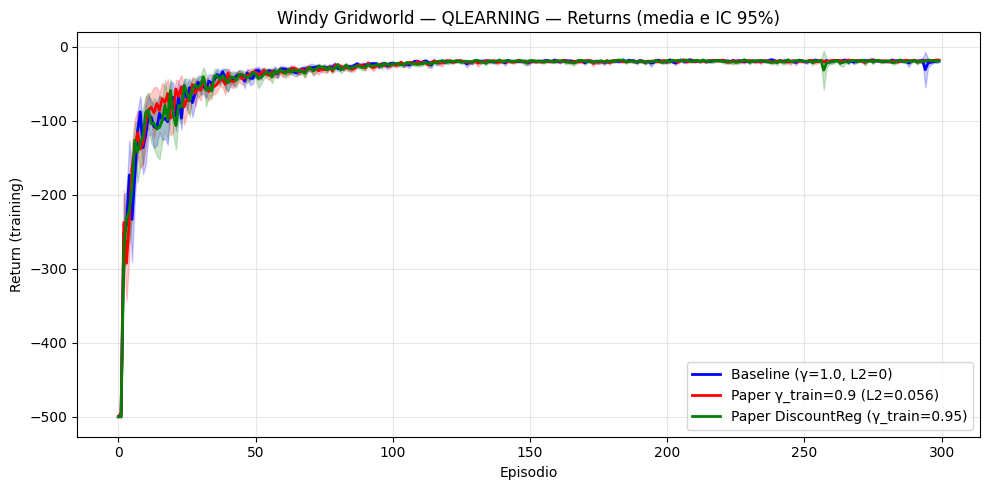

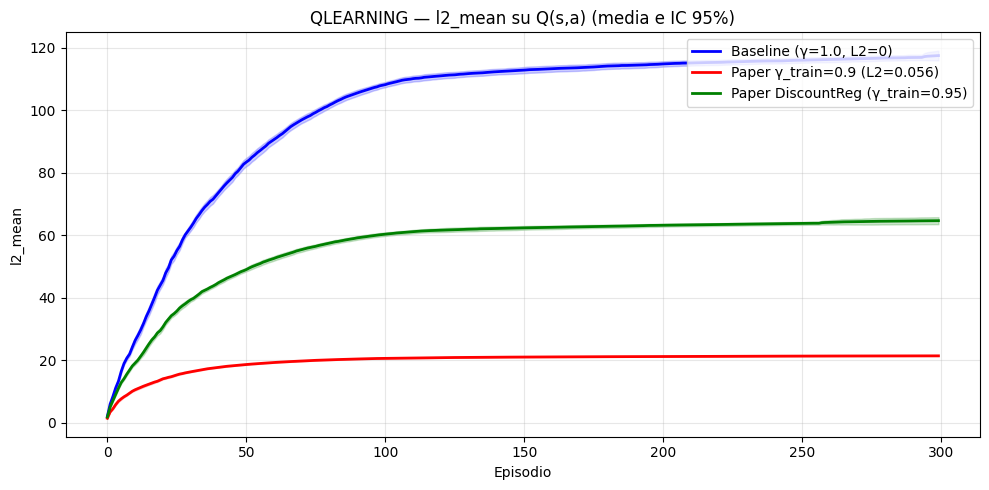

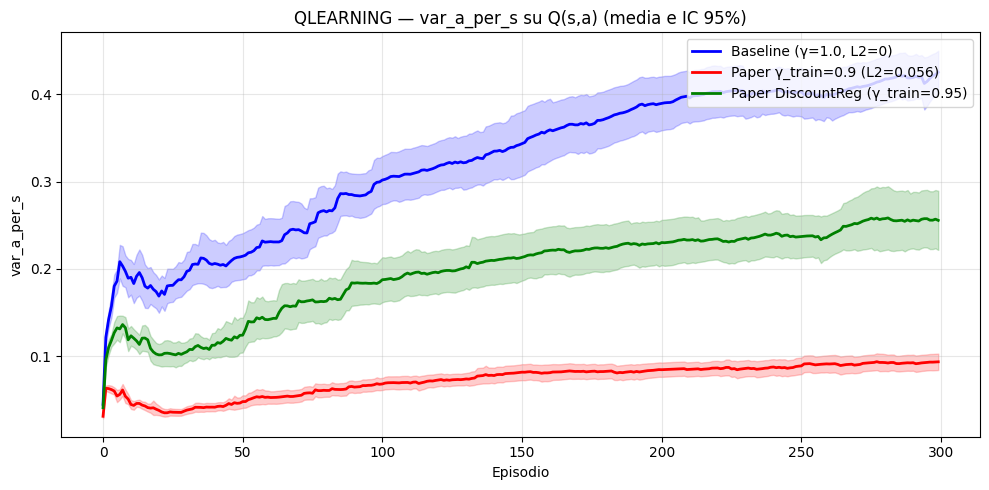

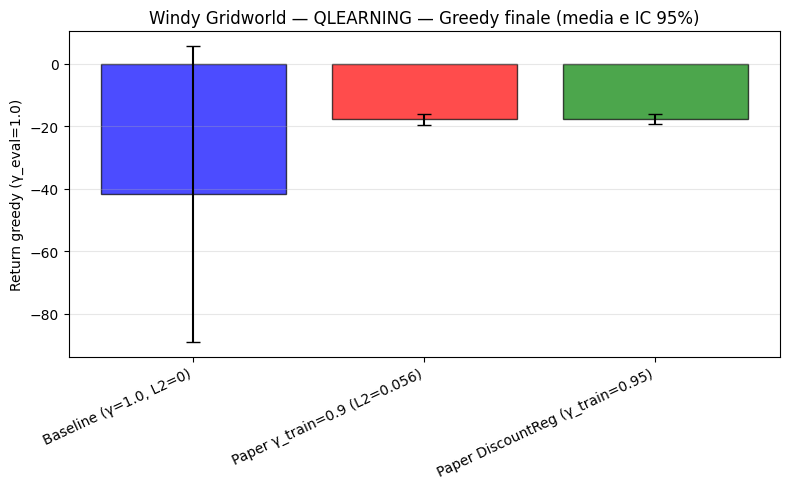


Baseline (γ=1.0, L2=0)
  l2_mean     : 1.1745e+02 ± 1.56e+00  (IC95 sulla media)
  max_abs     : 1.7044e+01 ± 5.87e-02  (IC95 sulla media)
  var_sa      : 3.5073e+01 ± 2.71e-01  (IC95 sulla media)
  var_a_per_s : 4.2538e-01 ± 2.46e-02  (IC95 sulla media)

Paper γ_train=0.9 (L2=0.056)
  l2_mean     : 2.1382e+01 ± 5.41e-02  (IC95 sulla media)
  max_abs     : 6.0019e+00 ± 2.27e-03  (IC95 sulla media)
  var_sa      : 5.3117e+00 ± 4.85e-02  (IC95 sulla media)
  var_a_per_s : 9.3648e-02 ± 9.41e-03  (IC95 sulla media)

Paper DiscountReg (γ_train=0.95)
  l2_mean     : 6.4629e+01 ± 1.13e+00  (IC95 sulla media)
  max_abs     : 1.1670e+01 ± 4.04e-02  (IC95 sulla media)
  var_sa      : 1.7844e+01 ± 2.27e-01  (IC95 sulla media)
  var_a_per_s : 2.5566e-01 ± 3.39e-02  (IC95 sulla media)
GREEDY FINALE (media ± IC95 sulla media) + varianza tra run
Baseline (γ=1.0, L2=0)                       :   -41.60 ±  47.31 | var=11653.3053
Paper γ_train=0.9 (L2=0.056)                 :   -17.70 ±   1.82 | var=17.

In [ ]:

# Parametri esperimento

algo = "qlearning"           # "qlearning" oppure "sarsa"
episodes = 300
alpha = 0.5
eps = 0.1
runs = 20
base_seed = 0

env_cfg = dict(
    stochastic=True,
    rows=7, cols=10,
    start=(3,0), goal=(3,7),
    wind_strengths=None,
    max_steps=500,
    stoch_p=0.1
)

gamma_eval = 1.0
gamma_low = 0.90
gamma_mid = 0.95
gamma_high = 1.0

# Metriche coerenti con il paper su Q(s,a)

def q_metrics_from_Q(Q):
    Q = np.asarray(Q)
    if Q.ndim != 3:
        raise ValueError(f"Forma di Q non attesa: {Q.shape}. Atteso (rows, cols, actions).")
    Q2 = Q.reshape(-1, Q.shape[-1])  # (S, A)

    l2_mean = float(np.mean(Q2**2))
    max_abs = float(np.max(np.abs(Q2)))
    var_sa = float(np.var(Q2))
    var_a_per_s = float(np.mean(np.var(Q2, axis=1)))
    return dict(l2_mean=l2_mean, max_abs=max_abs, var_sa=var_sa, var_a_per_s=var_a_per_s)

def train_sarsa_paper_logged(env, episodes=200, alpha=0.5, gamma=1.0, eps=0.1, seed=0, l2_lambda=0.0):
    rng = np.random.default_rng(seed)
    Q = init_Q(env)
    returns = np.zeros(episodes, dtype=float)
    metrics = {k: np.zeros(episodes, dtype=float) for k in q_metrics_from_Q(Q).keys()}

    for ep in range(episodes):
        s = env.reset()
        a = pick_action(Q, s, eps, rng)
        G = 0.0
        done = False

        while not done:
            ns = env.step(a)
            s_next, r, done = ns.next_state, ns.reward, ns.done
            G += r
            if not done:
                a_next = pick_action(Q, s_next, eps, rng)
                sarsa_update_l2(Q, s, a, r, s_next, a_next, alpha, gamma, l2_lambda=l2_lambda)
                s, a = s_next, a_next
            else:

                r0, c0 = s
                td_error = r - Q[r0, c0, a]
                Q[r0, c0, a] += alpha * (td_error - l2_lambda * Q[r0, c0, a])

        returns[ep] = G
        m = q_metrics_from_Q(Q)
        for kk, vv in m.items():
            metrics[kk][ep] = vv

    return Q, returns, metrics

def train_qlearning_paper_logged(env, episodes=200, alpha=0.5, gamma=1.0, eps=0.1, seed=0, l2_lambda=0.0):
    rng = np.random.default_rng(seed)
    Q = init_Q(env)
    returns = np.zeros(episodes, dtype=float)
    metrics = {k: np.zeros(episodes, dtype=float) for k in q_metrics_from_Q(Q).keys()}

    for ep in range(episodes):
        s = env.reset()
        G = 0.0
        done = False

        while not done:
            a = pick_action(Q, s, eps, rng)
            ns = env.step(a)
            s_next, r, done = ns.next_state, ns.reward, ns.done
            q_learning_update_l2(Q, s, a, r, s_next, alpha, gamma, l2_lambda=l2_lambda)
            s = s_next
            G += r

        returns[ep] = G
        m = q_metrics_from_Q(Q)
        for kk, vv in m.items():
            metrics[kk][ep] = vv

    return Q, returns, metrics
train_fn = train_sarsa_paper_logged if algo.lower() == "sarsa" else train_qlearning_paper_logged


curves = {}
metric_curves = {}
greedy_scores = {}


# Helper per aggregare metriche

def init_metric_store(metric_names, runs, episodes):
    return {nm: np.zeros((runs, episodes), dtype=float) for nm in metric_names}

def ci95_of_mean(mat):  # mat: (runs, T)
    mean = mat.mean(axis=0)
    var_mean = mat.var(axis=0, ddof=1) / mat.shape[0]
    ci95 = 1.96 * np.sqrt(var_mean)
    return mean, ci95


# RUN 1: Baseline
print(" BASELINE (γ_train=1.0, L2=0)")
key_baseline = "Baseline (γ=1.0, L2=0)"
rets = np.zeros((runs, episodes), dtype=float)
scores = np.zeros(runs, dtype=float)

tmp_env = make_env(**env_cfg, seed=base_seed)
tmp_Q = init_Q(tmp_env)
metric_names = list(q_metrics_from_Q(tmp_Q).keys())
mstore = init_metric_store(metric_names, runs, episodes)

for k in range(runs):
    env = make_env(**env_cfg, seed=base_seed + k)
    Q, ret, met = train_fn(env, episodes=episodes, alpha=alpha, gamma=1.0,
                           eps=eps, seed=base_seed + k, l2_lambda=0.0)
    rets[k] = ret
    for nm in metric_names:
        mstore[nm][k] = met[nm]

    env_eval = make_env(**env_cfg, seed=10_000 + base_seed + k)
    g, steps, ok = rollout_greedy(env_eval, Q, max_steps=500, gamma_eval=gamma_eval)
    scores[k] = g

curves[key_baseline] = rets
metric_curves[key_baseline] = mstore
greedy_scores[key_baseline] = scores


# RUN 2: Paper-style con gamma_low e L2 euristico (lambda)
print(f" PAPER γ_low={gamma_low} con L2 euristico")
l2_low = (gamma_eval - gamma_low) / (2.0 * gamma_low)
key_low = f"Paper γ_train={gamma_low} (L2={l2_low:.3f})"
rets = np.zeros((runs, episodes), dtype=float)
scores = np.zeros(runs, dtype=float)
mstore = init_metric_store(metric_names, runs, episodes)

for k in range(runs):
    env = make_env(**env_cfg, seed=base_seed + k)
    Q, ret, met = train_fn(env, episodes=episodes, alpha=alpha, gamma=gamma_low,
                           eps=eps, seed=base_seed + k, l2_lambda=l2_low)
    rets[k] = ret
    for nm in metric_names:
        mstore[nm][k] = met[nm]

    env_eval = make_env(**env_cfg, seed=10_000 + base_seed + k)
    g, steps, ok = rollout_greedy(env_eval, Q, max_steps=500, gamma_eval=gamma_eval)
    scores[k] = g

curves[key_low] = rets
metric_curves[key_low] = mstore
greedy_scores[key_low] = scores

# RUN 3: Discount regularization (solo gamma più basso, L2=0)
print(f" PAPER DiscountReg γ_train={gamma_mid} (L2=0)")
key_mid = f"Paper DiscountReg (γ_train={gamma_mid})"
rets = np.zeros((runs, episodes), dtype=float)
scores = np.zeros(runs, dtype=float)
mstore = init_metric_store(metric_names, runs, episodes)

for k in range(runs):
    env = make_env(**env_cfg, seed=base_seed + k)
    Q, ret, met = train_fn(env, episodes=episodes, alpha=alpha, gamma=gamma_mid,
                           eps=eps, seed=base_seed + k, l2_lambda=0.0)
    rets[k] = ret
    for nm in metric_names:
        mstore[nm][k] = met[nm]

    env_eval = make_env(**env_cfg, seed=10_000 + base_seed + k)
    g, steps, ok = rollout_greedy(env_eval, Q, max_steps=500, gamma_eval=gamma_eval)
    scores[k] = g

curves[key_mid] = rets
metric_curves[key_mid] = mstore
greedy_scores[key_mid] = scores

# PLOT: returns con IC95

labels = list(curves.keys())
colors = ['blue', 'red', 'green']

plt.figure(figsize=(10, 5))
for label, color in zip(labels, colors):
    mat = curves[label]
    mean, ci95 = ci95_of_mean(mat)
    plt.plot(mean, label=label, color=color, linewidth=2)
    plt.fill_between(np.arange(episodes), mean-ci95, mean+ci95, color=color, alpha=0.2)
plt.xlabel("Episodio")
plt.ylabel("Return (training)")
plt.title(f"Windy Gridworld — {algo.upper()} — Returns (media e IC 95%)")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# PLOT: metriche chiave per vedere l'ipotesi del paper (l2_mean e var_a_per_s)

def plot_metric(metric_name):
    plt.figure(figsize=(10, 5))
    for label, color in zip(labels, colors):
        mat = metric_curves[label][metric_name]
        mean, ci95 = ci95_of_mean(mat)
        plt.plot(mean, label=label, color=color, linewidth=2)
        plt.fill_between(np.arange(episodes), mean-ci95, mean+ci95, color=color, alpha=0.2)
    plt.xlabel("Episodio")
    plt.ylabel(metric_name)
    plt.title(f"{algo.upper()} — {metric_name} su Q(s,a) (media e IC 95%)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_metric("l2_mean")
plot_metric("var_a_per_s")


# BARPLOT: greedy finale con IC95 + varianza

plt.figure(figsize=(8, 5))
means = []
ci95s = []
vars_ = []
for label in labels:
    v = greedy_scores[label]
    means.append(v.mean())
    vars_.append(v.var(ddof=1))
    ci95s.append(1.96 * np.sqrt(vars_[-1] / len(v)))

x = np.arange(len(labels))
plt.bar(x, means, yerr=ci95s, capsize=5, color=colors, alpha=0.7, edgecolor='black')
plt.xticks(x, labels, rotation=25, ha="right", fontsize=10)
plt.ylabel("Return greedy (γ_eval=1.0)")
plt.title(f"Windy Gridworld — {algo.upper()} — Greedy finale (media e IC 95%)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# STAMPE: riassunti che rispondono direttamente all'ipotesi

for label in labels:
    print(f"\n{label}")
    for nm in ["l2_mean", "max_abs", "var_sa", "var_a_per_s"]:
        last = metric_curves[label][nm][:, -1]  # (runs,)
        mu = last.mean()
        se = last.std(ddof=1) / np.sqrt(len(last))
        print(f"  {nm:12s}: {mu:.4e} ± {1.96*se:.2e}  (IC95 sulla media)")

print("GREEDY FINALE (media ± IC95 sulla media) + varianza tra run")
for label in labels:
    v = greedy_scores[label]
    mu = v.mean()
    var = v.var(ddof=1)
    ci95 = 1.96 * np.sqrt(var / len(v))
    print(f"{label:45s}: {mu:8.2f} ± {ci95:6.2f} | var={var:.4f}")

